In [1]:
import pandas as pd

ftse = pd.read_csv("ftse100_close_2015_2026.csv", parse_dates=["date"], index_col="date")["close"]
returns = ftse.pct_change().dropna() * 100
returns.describe()

count    2955.000000
mean        0.021113
std         0.959447
min       -10.873819
25%        -0.418593
50%         0.059714
75%         0.499350
max         9.053047
Name: close, dtype: float64

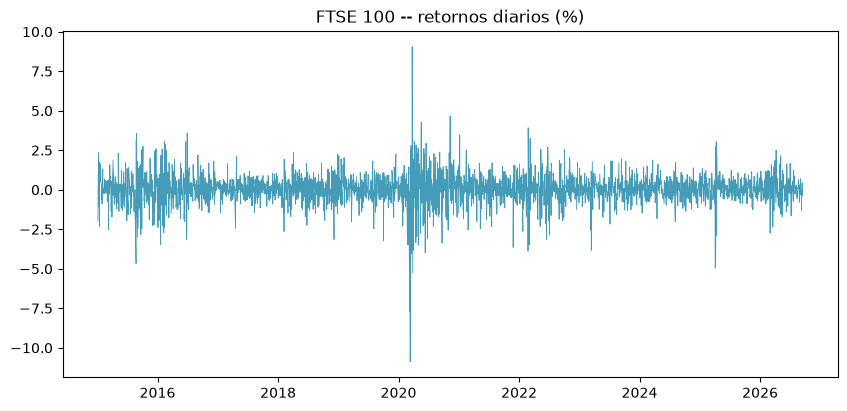

In [2]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(returns.index, returns, color="#449cb9", linewidth=0.6)
ax.set_title("FTSE 100 -- retornos diarios (%)")
plt.savefig("ftse-retornos-clustering.png", dpi=150, bbox_inches="tight")
plt.show()

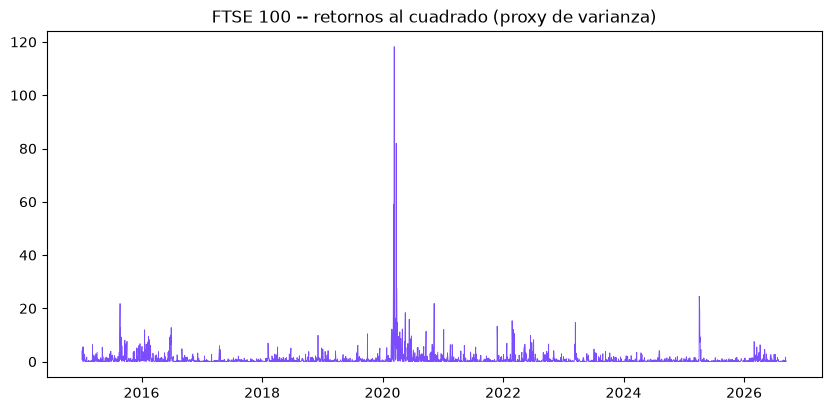

In [3]:
retornos_cuadrado = returns ** 2

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(retornos_cuadrado.index, retornos_cuadrado, color="#7c4dff", linewidth=0.6)
ax.set_title("FTSE 100 -- retornos al cuadrado (proxy de varianza)")
plt.savefig("ftse-retornos-cuadrado.png", dpi=150, bbox_inches="tight")
plt.show()

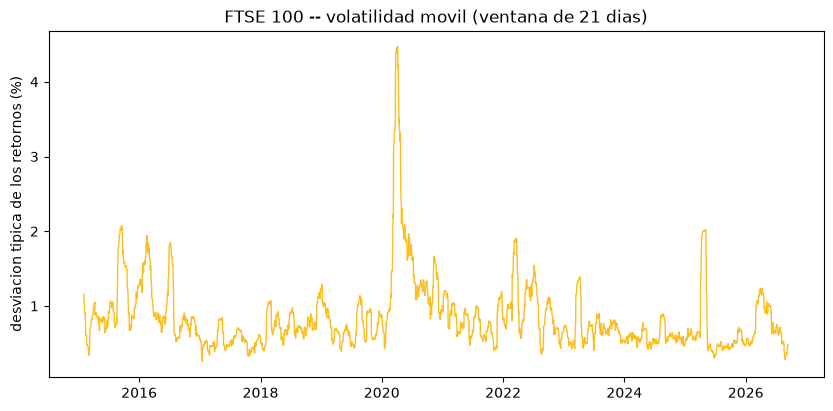

In [4]:
vol_rolling = returns.rolling(21).std()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(vol_rolling.index, vol_rolling, color="#fbbf24", linewidth=1.0)
ax.set_title("FTSE 100 -- volatilidad movil (ventana de 21 dias)")
ax.set_ylabel("desviacion tipica de los retornos (%)")
plt.savefig("ftse-vol-rolling.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_retornos = acorr_ljungbox(returns, lags=[10], return_df=True)
lb_cuadrado = acorr_ljungbox(retornos_cuadrado, lags=[10], return_df=True)

print("Ljung-Box sobre los retornos (nivel):")
print(lb_retornos)
print()
print("Ljung-Box sobre los retornos al cuadrado:")
print(lb_cuadrado)

Ljung-Box sobre los retornos (nivel):
      lb_stat  lb_pvalue
10  28.518397    0.00149

Ljung-Box sobre los retornos al cuadrado:
        lb_stat      lb_pvalue
10  1392.893787  3.394657e-293


In [6]:
from statsmodels.stats.diagnostic import het_arch

estadistico, pvalor, f_stat, f_pvalor = het_arch(returns, nlags=10)
print("Engle's ARCH LM test (10 lags)")
print("estadistico LM:", estadistico)
print("p-value      :", pvalor)

Engle's ARCH LM test (10 lags)
estadistico LM: 716.1991097630752
p-value      : 2.0893338977838973e-147


/Users/juangabriel/.cache/uv/archive-v0/dW2Qo-dJS1TMINvy/lib/python3.11/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(
